In [2]:
import pandas as pd
from sqlalchemy import create_engine, types
from sqlalchemy import text # to be able to pass string

# 1. Set up connection (update credentials and host!)
from dotenv import dotenv_values

config = dotenv_values() 

# define variables for the login
pg_user = config['POSTGRES_USER']  # align the key label with your .env file !
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = config['POSTGRES_PASS']

url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'

engine = create_engine(url, echo=False)

# 2. Load data

my_schema = "team_3"

mart_all_data = pd.read_sql(
    f"SELECT * FROM {my_schema}.mart_all_data;",
    engine,
    parse_dates=['transaction_date']
)

# Customer demographic data (for segmentation)
mart_customers = pd.read_sql(
    f"SELECT * FROM {my_schema}.mart_customers;",
    engine
)

In [3]:
mart_all_data.head()


,transaction_date,transaction_id,customer_id,customer_gender,customer_location,customer_tenure_months,produkt_sku,product_category,quantity,avg_price,delivery_charges,revenue,coupon_status,discount_pct,gst_onsale,daily_offline,daily_online,transaction_month,transaction_month_str
0,2019-04-19,25990,15811,F,Illinois,27,GGOEWCKQ085457,Accessories,1,16.99,6.0,22.99,Clicked,10.0,0.1,4000,1754.92,4.0,apr
1,2019-04-07,25038,17999,F,New Jersey,30,GGOEGBPB081999,Accessories,1,49.99,6.5,56.49,Used,10.0,0.1,2500,2719.46,4.0,apr
2,2019-04-07,25038,17999,F,New Jersey,30,GGOEGBPB082099,Accessories,1,59.99,6.5,66.49,Clicked,10.0,0.1,2500,2719.46,4.0,apr
3,2019-04-28,26637,18116,F,Illinois,38,GGOEGBPB081999,Accessories,1,39.99,6.0,45.99,Clicked,10.0,0.1,3500,2019.73,4.0,apr
4,2019-08-02,34452,16889,F,Illinois,23,GGOEGBPB081999,Accessories,1,34.99,6.0,40.99,Used,20.0,0.1,1500,2155.96,8.0,aug


In [4]:
mart_all_data['revenue'] = mart_all_data['quantity'] * mart_all_data['avg_price'] + mart_all_data['delivery_charges']

In [5]:
cutoff_date = pd.Timestamp('2019-04-01')
future_6m_end = cutoff_date + pd.DateOffset(days=180)

customers_before_cutoff = mart_all_data[mart_all_data['transaction_date'] < cutoff_date]['customer_id'].unique()

actual_ltv = (
    mart_all_data[
        (mart_all_data['customer_id'].isin(customers_before_cutoff)) &
        (mart_all_data['transaction_date'] >= cutoff_date) &
        (mart_all_data['transaction_date'] < future_6m_end)
    ]
    .groupby('customer_id')['revenue'].sum()
    .reset_index()
    .rename(columns={'revenue': 'actual_LTV_6m'})
)


In [6]:
# Add Predicted LTV

eval_df = actual_ltv



In [7]:
# Merge with Customer Segments

segment_df = eval_df.merge(mart_customers, on='customer_id', how='left')



In [8]:
# Segment Analysis Example (by Gender or Location)

# You can analyze by gender, location, or any customer field.
segment = 'gender'  # or 'customer_location' or another categorical column

segment_stats = (
    segment_df.groupby(segment)
    .agg(
        n_customers = ('customer_id', 'count'),
        mean_actual_LTV_6m = ('actual_LTV_6m', 'mean'),
        median_actual_LTV_6m = ('actual_LTV_6m', 'median'),
        return_rate = ('actual_LTV_6m', lambda x: (x > 0).mean())
    )
    .reset_index()
)
print(segment_stats)


  gender  n_customers  mean_actual_LTV_6m  median_actual_LTV_6m  return_rate
0      F          158         3645.422595              1682.410          1.0
1      M           98         3205.291020              1546.245          1.0


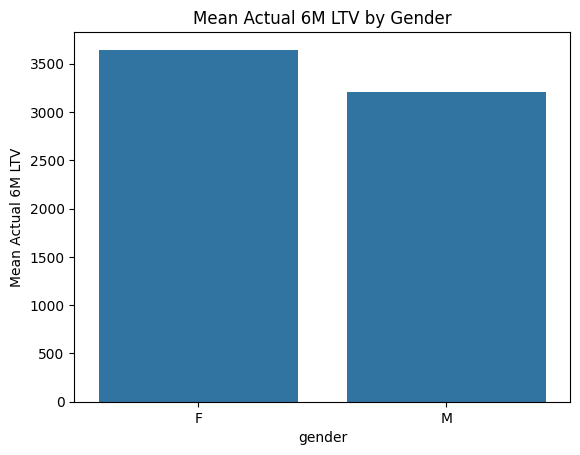

In [9]:
#7.  Visualize

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x=segment, y='mean_actual_LTV_6m', data=segment_stats)
plt.title(f'Mean Actual 6M LTV by {segment.title()}')
plt.ylabel('Mean Actual 6M LTV')
plt.show()

In [10]:
segment = 'location'
segment_stats = (
    segment_df.groupby(segment)
    .agg(
        n_customers = ('customer_id', 'count'),
        mean_actual_LTV_6m = ('actual_LTV_6m', 'mean'),
        median_actual_LTV_6m = ('actual_LTV_6m', 'median'),
        return_rate = ('actual_LTV_6m', lambda x: (x > 0).mean())
    )
    .reset_index()
)
print(segment_stats)


        location  n_customers  mean_actual_LTV_6m  median_actual_LTV_6m  \
0     California           81         3773.367654              1914.390   
1       Illinois           75         5050.904533              1893.750   
2     New Jersey           21         2033.113810               562.430   
3       New York           62         2180.857097              1089.815   
4  Washington DC           17         1630.949412              1129.490   

   return_rate  
0          1.0  
1          1.0  
2          1.0  
3          1.0  
4          1.0  


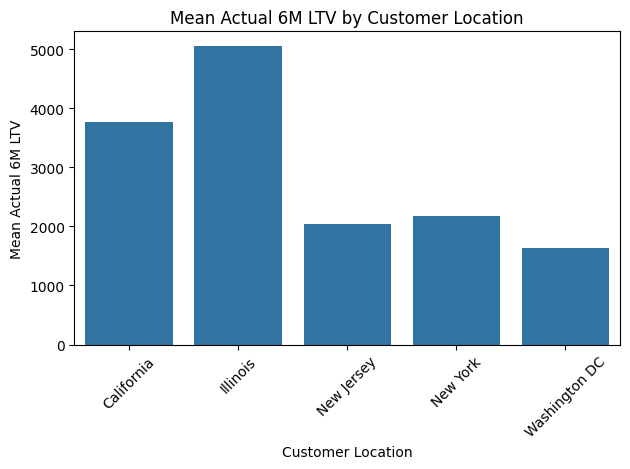

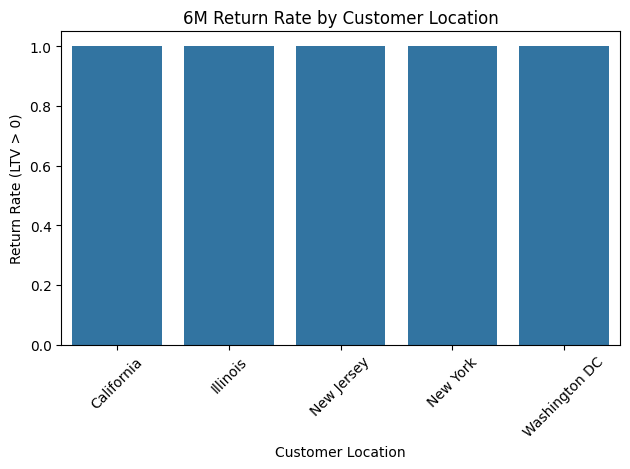

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Barplot: Mean LTV by location
sns.barplot(x=segment, y='mean_actual_LTV_6m', data=segment_stats)
plt.title('Mean Actual 6M LTV by Customer Location')
plt.ylabel('Mean Actual 6M LTV')
plt.xlabel('Customer Location')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Barplot: Return rate by location
sns.barplot(x=segment, y='return_rate', data=segment_stats)
plt.title('6M Return Rate by Customer Location')
plt.ylabel('Return Rate (LTV > 0)')
plt.xlabel('Customer Location')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()





In [12]:
# Calculate total revenue and total orders per customer in the PRE-CUTOFF period
cutoff_date = pd.Timestamp('2019-04-01')

pre_cutoff = mart_all_data[mart_all_data['transaction_date'] < cutoff_date]

aov_df = (
    pre_cutoff.groupby('customer_id')
    .agg(
        total_revenue=('revenue', 'sum'),
        n_orders=('transaction_id', 'nunique')
    )
    .reset_index()
)
aov_df['AOV'] = aov_df['total_revenue'] / aov_df['n_orders']

In [13]:
# Merge AOV with actual LTV and customer info
aov_segment_df = eval_df.merge(aov_df[['customer_id', 'AOV']], on='customer_id', how='left')
aov_segment_df = aov_segment_df.merge(mart_customers, on='customer_id', how='left')


In [14]:
# For example, quartiles:
aov_segment_df['AOV_segment'] = pd.qcut(aov_segment_df['AOV'], q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])
# Or use custom bins, e.g.:
# aov_segment_df['AOV_segment'] = pd.cut(aov_segment_df['AOV'], bins=[0, 50, 150, 500, np.inf], labels=['Very Low', 'Low', 'Medium', 'High'])


Segment-level LTV Analysis


In [16]:
segment = 'AOV_segment'
segment_stats = (
    aov_segment_df.groupby(segment)
    .agg(
        n_customers = ('customer_id', 'count'),
        mean_actual_LTV_6m = ('actual_LTV_6m', 'mean'),
        median_actual_LTV_6m = ('actual_LTV_6m', 'median'),
        mean_AOV = ('AOV', 'mean'),
        median_AOV = ('AOV', 'median'),
        return_rate = ('actual_LTV_6m', lambda x: (x > 0).mean())
    )
    .reset_index()
)
print(segment_stats)

   AOV_segment  n_customers  mean_actual_LTV_6m  median_actual_LTV_6m  \
0          Low           64         2300.352656              1142.935   
1   Medium-Low           64         2857.320312              1259.605   
2  Medium-High           64         5530.321875              2274.980   
3         High           64         3219.744062              1807.635   

     mean_AOV  median_AOV  return_rate  
0   82.877339   90.280000          1.0  
1  153.892459  155.604167          1.0  
2  200.373059  200.727662          1.0  
3  346.580228  306.018333          1.0  


/var/folders/30/dsmll_zd0y99rxph1kl1nzc80000gp/T/ipykernel_23530/1142196527.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aov_segment_df.groupby(segment)


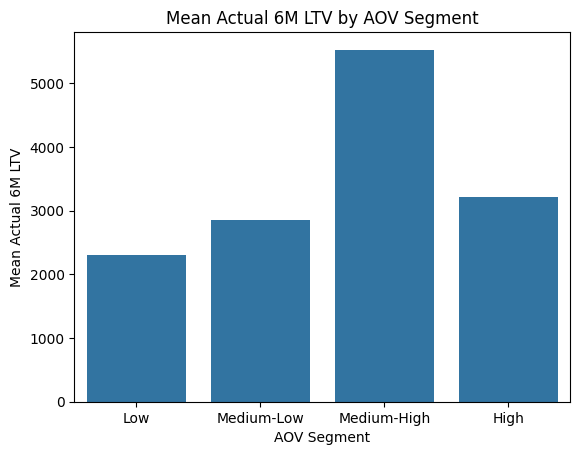

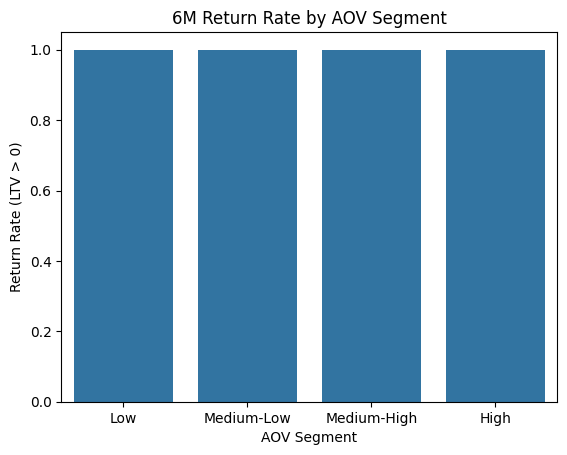

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot mean LTV by AOV segment
sns.barplot(x=segment, y='mean_actual_LTV_6m', data=segment_stats, order=['Low','Medium-Low','Medium-High','High'])
plt.title('Mean Actual 6M LTV by AOV Segment')
plt.ylabel('Mean Actual 6M LTV')
plt.xlabel('AOV Segment')
plt.show()

# Plot return rate by AOV segment
sns.barplot(x=segment, y='return_rate', data=segment_stats, order=['Low','Medium-Low','Medium-High','High'])
plt.title('6M Return Rate by AOV Segment')
plt.ylabel('Return Rate (LTV > 0)')
plt.xlabel('AOV Segment')
plt.show()


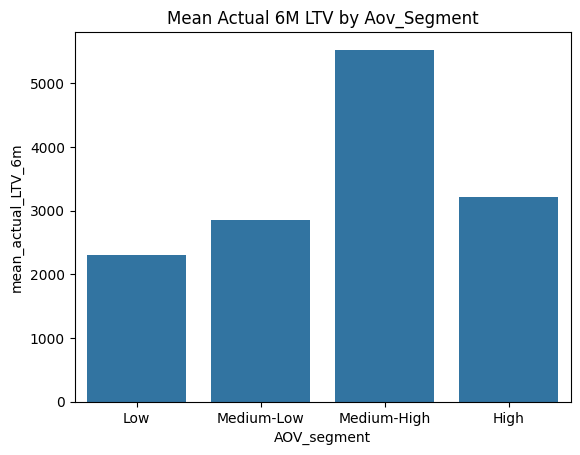

In [18]:
# Barplots of Mean/Median LTV by Segment
sns.barplot(x=segment, y='mean_actual_LTV_6m', data=segment_stats)
plt.title(f"Mean Actual 6M LTV by {segment.title()}")
plt.show()

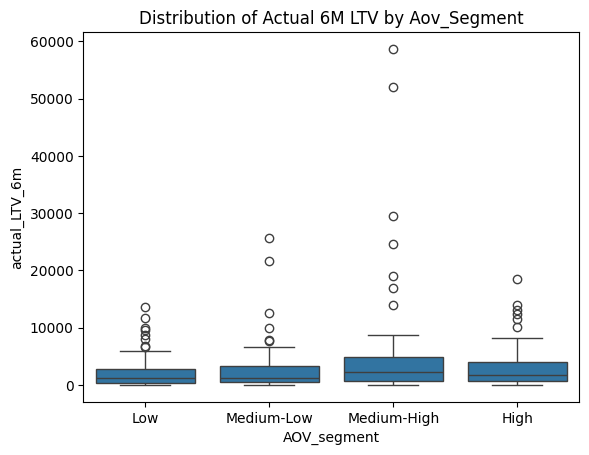

In [19]:
sns.boxplot(x=segment, y='actual_LTV_6m', data=aov_segment_df)
plt.title(f"Distribution of Actual 6M LTV by {segment.title()}")
plt.show()


In [20]:
print(aov_segment_df.columns)

Index(['customer_id', 'actual_LTV_6m', 'AOV', 'gender', 'location',
       'tenure_months', 'AOV_segment'],
      dtype='object')


In [21]:
# Create tenure bins
aov_segment_df['tenure_bin'] = pd.cut(
    aov_segment_df['tenure_months'], 
    bins=[0,12,24,36,48,60,100],
    right=False,
    labels=['0-12','12-24','24-36','36-48','48-60','60+']
)

/var/folders/30/dsmll_zd0y99rxph1kl1nzc80000gp/T/ipykernel_23530/3806146396.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = aov_segment_df.pivot_table(


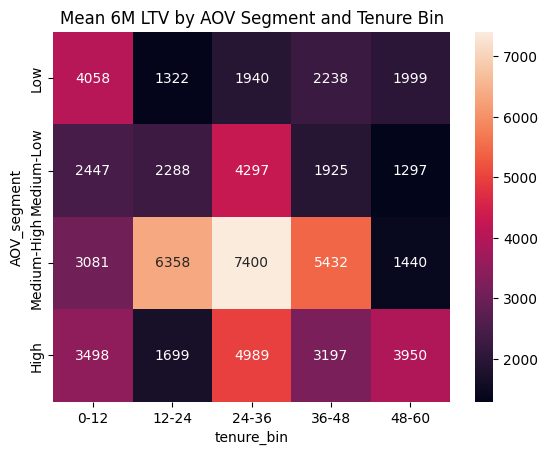

In [22]:
pivot = aov_segment_df.pivot_table(
    index='AOV_segment', columns='tenure_bin', values='actual_LTV_6m', aggfunc='mean'
)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(pivot, annot=True, fmt='.0f')
plt.title("Mean 6M LTV by AOV Segment and Tenure Bin")
plt.show()

Summary table

|             | 0-12 | 12-24 | 24-36 | 36-48 | 48-60 |
| ----------- | ---- | ----- | ----- | ----- | ----- |
| Low         | 4058 | 1322  | 1940  | 2238  | 1999  |
| Medium-Low  | 2447 | 2288  | 4297  | 1925  | 1297  |
| Medium-High | 3081 | 6358  | 7400  | 5432  | 1440  |
| High        | 3498 | 1699  | 4989  | 3197  | 3950  |


Business Insights
“Medium-High AOV, 24-36 months tenure” is our superstar group (highest mean LTV).

Low tenure often means lower LTV, except for some segments.

Not always true that High AOV → High LTV for every tenure bin. Check for churn or discount-seeking.

You can target the highest cells for premium marketing,
or investigate why some segments underperform.

Customer Count per Segment 

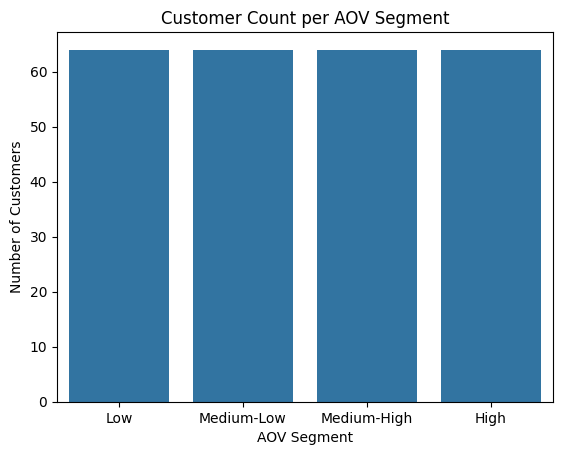

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='AOV_segment', data=aov_segment_df, order=['Low', 'Medium-Low', 'Medium-High', 'High'])
plt.title('Customer Count per AOV Segment')
plt.ylabel('Number of Customers')
plt.xlabel('AOV Segment')
plt.show()


Cumulative Revenue Curve by Segment (“Whale Curve”)

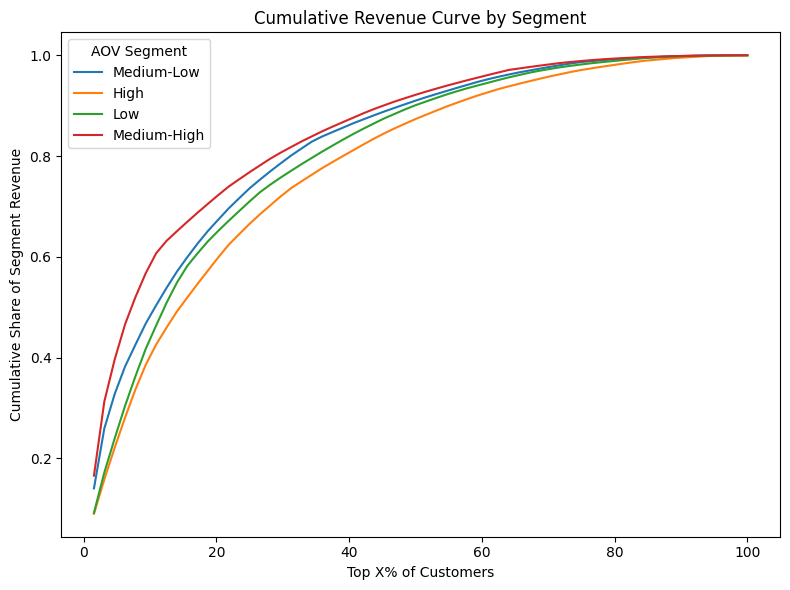

In [25]:
import numpy as np

plt.figure(figsize=(8, 6))
for seg in aov_segment_df['AOV_segment'].unique():
    sub = aov_segment_df[aov_segment_df['AOV_segment'] == seg].copy()
    # Sort customers by actual LTV
    sub = sub.sort_values('actual_LTV_6m', ascending=False)
    # Cumulative revenue share
    cumsum = sub['actual_LTV_6m'].cumsum() / sub['actual_LTV_6m'].sum()
    # Customer percentiles
    pct = np.arange(1, len(sub) + 1) / len(sub)
    plt.plot(pct * 100, cumsum, label=seg)
plt.title('Cumulative Revenue Curve by Segment')
plt.xlabel('Top X% of Customers')
plt.ylabel('Cumulative Share of Segment Revenue')
plt.legend(title='AOV Segment')
plt.tight_layout()
plt.show()

X-axis: Top % of customers in each AOV segment (sorted by LTV, left = highest LTV customers)

Y-axis: Cumulative share of total segment revenue contributed by those top customers

Interpretation & Insights
Steepness of the curve:

If the curve rises quickly (especially for the red Medium-High segment), a small % of customers drive a large share of the revenue (“whale effect”).

For example, in the Medium-High AOV segment, the top ~20% of customers contribute well over 60% of the segment’s total revenue.

Flatter curves (like High or Low) indicate revenue is spread more evenly across customers.

Comparison between segments:

Medium-High AOV (red): Most “whale-heavy”—a few customers are extremely valuable.

High AOV (orange): More evenly distributed revenue; no single “whale” effect.

Medium-Low/Low: Somewhere in between; still some concentration at the top.

Actionable takeaways:

Target your “whales”: Medium-High AOV customers at the top percentiles deserve special attention (retention, upsell, loyalty).

For segments with flatter curves, broad-based offers or mass campaigns may be more appropriate.

Typical Observations:
In most e-commerce datasets, top 20% of customers can deliver 60–80% of revenue (“Pareto principle”).

You can quantify this by reading off the Y-axis at X=20 for each segment.

In [26]:
whale_stats = []

for seg in aov_segment_df['AOV_segment'].unique():
    sub = aov_segment_df[aov_segment_df['AOV_segment'] == seg].copy()
    sub = sub.sort_values('actual_LTV_6m', ascending=False)
    n = len(sub)
    # Top 10%
    top_10 = int(np.ceil(0.10 * n))
    rev_10pct = sub['actual_LTV_6m'].iloc[:top_10].sum() / sub['actual_LTV_6m'].sum()
    # Top 20%
    top_20 = int(np.ceil(0.20 * n))
    rev_20pct = sub['actual_LTV_6m'].iloc[:top_20].sum() / sub['actual_LTV_6m'].sum()
    whale_stats.append({'AOV_segment': seg, 'Revenue_top10%': rev_10pct, 'Revenue_top20%': rev_20pct})

whale_df = pd.DataFrame(whale_stats)
# Format as percentages
whale_df['Revenue_top10%'] = (whale_df['Revenue_top10%'] * 100).round(1)
whale_df['Revenue_top20%'] = (whale_df['Revenue_top20%'] * 100).round(1)

print(whale_df)

   AOV_segment  Revenue_top10%  Revenue_top20%
0   Medium-Low            50.4            67.4
1         High            42.6            59.9
2          Low            46.4            65.2
3  Medium-High            60.7            72.3


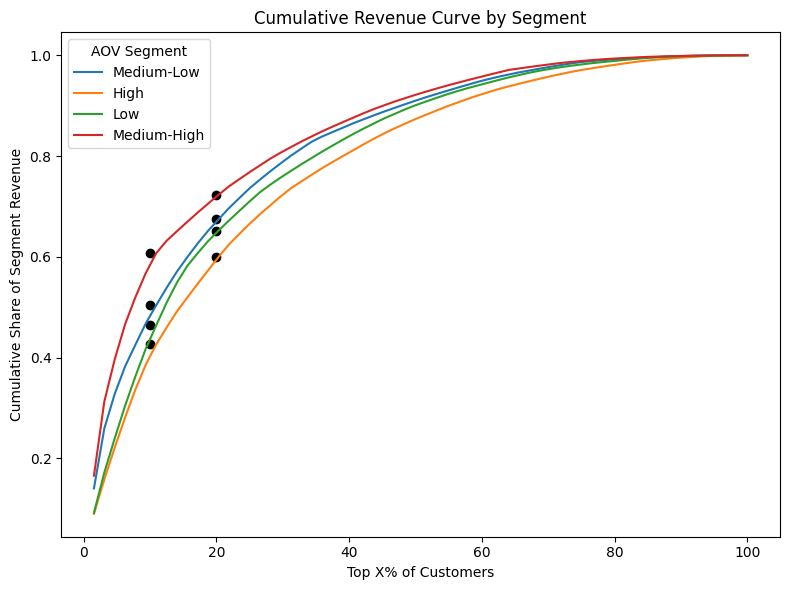

In [27]:
plt.figure(figsize=(8, 6))
for seg in aov_segment_df['AOV_segment'].unique():
    sub = aov_segment_df[aov_segment_df['AOV_segment'] == seg].copy()
    sub = sub.sort_values('actual_LTV_6m', ascending=False)
    cumsum = sub['actual_LTV_6m'].cumsum() / sub['actual_LTV_6m'].sum()
    pct = np.arange(1, len(sub) + 1) / len(sub)
    plt.plot(pct * 100, cumsum, label=seg)
    # Add dots at 10% and 20%
    n = len(sub)
    idx_10 = int(np.ceil(0.10 * n)) - 1
    idx_20 = int(np.ceil(0.20 * n)) - 1
    plt.scatter(10, cumsum.iloc[idx_10], color='black', marker='o')
    plt.scatter(20, cumsum.iloc[idx_20], color='black', marker='o')

plt.title('Cumulative Revenue Curve by Segment')
plt.xlabel('Top X% of Customers')
plt.ylabel('Cumulative Share of Segment Revenue')
plt.legend(title='AOV Segment')
plt.tight_layout()
plt.show()

In [28]:
# Define LTV buckets 
import numpy as np
import pandas as pd

bins = [0, 1, 500, 2000, np.inf]  # [0, $1), [$1–500), [$500–2000), [$2000+)
labels = ['$0', '$1–500', '$500–2k', '$2k+']

aov_segment_df['LTV_bucket'] = pd.cut(aov_segment_df['actual_LTV_6m'], bins=bins, labels=labels, right=False)


In [29]:
# Count customers by AOV segment and LTV bucket
stacked = (
    aov_segment_df
    .groupby(['AOV_segment', 'LTV_bucket'])['customer_id']
    .count()
    .reset_index()
    .pivot(index='AOV_segment', columns='LTV_bucket', values='customer_id')
    .fillna(0)
)

/var/folders/30/dsmll_zd0y99rxph1kl1nzc80000gp/T/ipykernel_23530/1913768296.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['AOV_segment', 'LTV_bucket'])['customer_id']


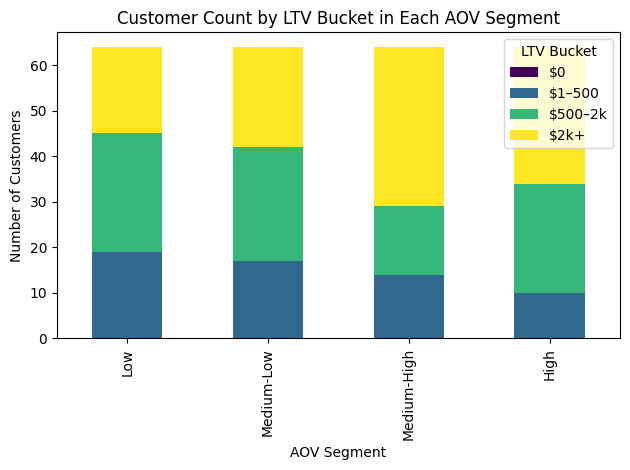

In [30]:
import matplotlib.pyplot as plt

# Plot
stacked[labels].plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Customer Count by LTV Bucket in Each AOV Segment')
plt.xlabel('AOV Segment')
plt.ylabel('Number of Customers')
plt.legend(title='LTV Bucket')
plt.tight_layout()
plt.show()
